In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [2]:
L_list = [6, 8, 10, 12, 14]
N_list = [4, 5, 7, 8, 9]
Na_list = [2, 2, 3, 4, 4]

In [3]:
from scipy.special import comb

In [ ]:
results_dir = "results/thermalization"

data = {}
for L in L_list:
    path = f"{results_dir}/n_profile_vs_t_L{L}.csv"
    df = pd.read_csv(path, comment="#")
    df.columns = df.columns.str.strip()
    data[L] = df
    print(f"L={L}: {df.shape[0]} timesteps, columns: {list(df.columns)}")

In [5]:
def ceiling(L, N):
    LA = L // 2
    LB = L - LA
    n_min = max(0, N - LB)
    n_max = min(N, LA)
    dA = sum(comb(LA, n) * 2**n for n in range(n_min, n_max + 1))
    return np.log2(dA)

# def ceiling(L, N):
#     D = comb(L, N) * 2**N
#     return np.log(D) - np.log(2)

In [6]:
ceiling_list = [ceiling(L-2, N-2) for L, N in zip(L_list, N_list)]

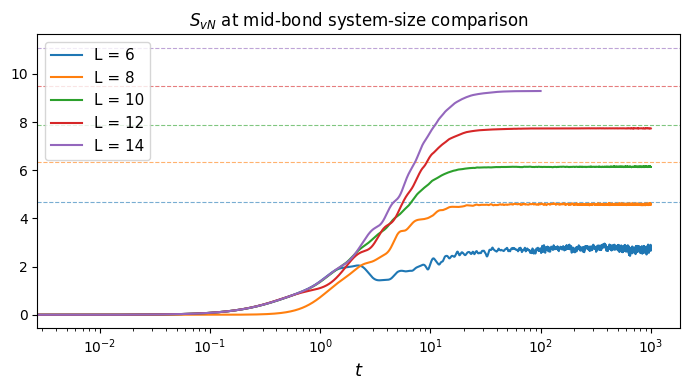

In [7]:
fig, ax = plt.subplots(figsize=(7,4))
colors = ["C0", "C1", "C2", "C3", "C4"]
for L, N, color, ceilings in zip(L_list, N_list, colors, ceiling_list):
    # print(ceiling(L-2,N-2))
    ax.plot(data[L]["time"], data[L]["S_mid"], label=f"L = {L}", color = color)
    # ax.axhline(ceilings, ls="--", lw=0.8, alpha=0.6, color = color)
    ax.axhline(ceiling(L,N), ls="--", lw=0.8, alpha=0.6, color = color)
ax.set_xscale("log")
ax.set_xlabel(r"$t$", fontsize=13)
# ax.set_ylabel(r"$\langle \chi_\mathrm{ent} \rangle$", fontsize=13)
ax.set_title(r"$S_{vN}$ at mid-bond system-size comparison")
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

In [8]:
# f = 1-1/np.exp(1)
f = 0.99

In [9]:
for L, N, ceilings in zip(L_list, N_list, ceiling_list):
    n_tail = max(1, int(0.1 * len(data[L]["S_mid"])))
    plateau = data[L]["S_mid"].iloc[-n_tail:].mean()
    reached = data[L]["S_mid"] >= f * plateau
    t_therm = data[L]["time"][reached].iloc[0] if reached.any() else float("nan")
    print(f" {L}    {plateau:9.4f}  {t_therm:9.4f}")

 6       2.7421    35.9050
 8       4.5863    21.0900
 10       6.1407    22.0450
 12       7.7375    28.1550
 14       9.2866    30.6900


In [10]:
step = int(30.6900/0.005)

In [11]:
C_list = [f"C{i}" for i in range(0, 14)]

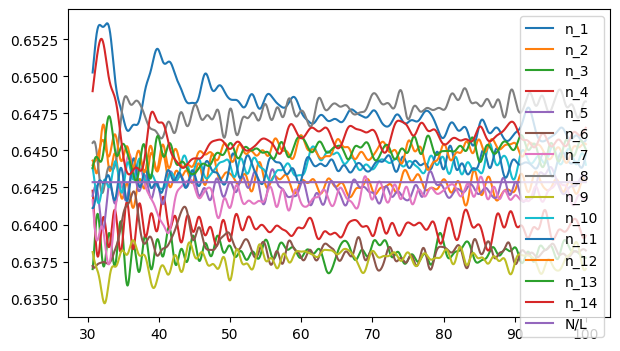

In [12]:
plt.figure(figsize=(7,4))
for i, colors in zip(range(1, 15), C_list):
    plt.plot(data[14]['time'][step:], data[14][f'n_{i}'][step:], label=f"n_{i}", color = colors)
plt.plot(data[14]['time'][step:], [9/14 for i in data[14]['time'][step:]], label="N/L", color="C14")
plt.legend()
plt.show()

In [13]:
for i in range(1, 15):
    l = np.shape(data[14][f'n_{i}'][step:])[0]
    print(np.sum(data[14][f'n_{i}'][step:])/l)

0.6477469797279911
0.6429261087235923
0.6381645722121576
0.6398043375382485
0.642401607708625
0.6383837744037184
0.6418939824035628
0.6475504200344918
0.6376171052368637
0.6439382861366899
0.6437589574675662
0.6448939892366169
0.6449494276218835
0.6459704515479492


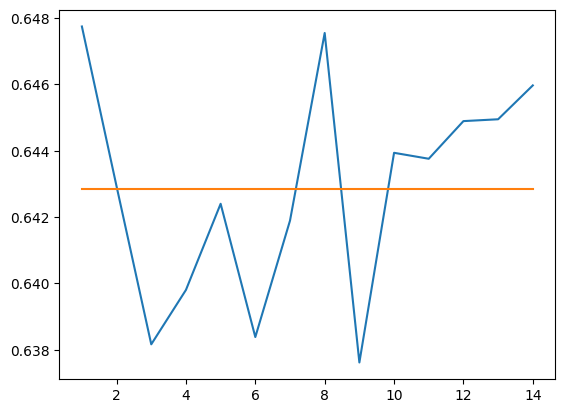

In [14]:
plt.plot([i for i in range(1, 15)], [np.sum(data[14][f'n_{i}'][step:])/np.shape(data[14][f'n_{i}'][step:])[0] for i in range(1, 15)])
plt.plot([i for i in range(1, 15)], [N/L for i in range(1, 15)])